# Tensorboard with Pytorch

Tensorboard is a visualization tool associated with the TensorFlow ecosystem. It is so popular that it is also supported in Pytorch and is commonly used. It allows you to visualize:

- Metrics such as *loss* or *accuracy*.
- The graph that represents the architecture of the model
- Real-time evolution of weight and bias histograms
- Computational performance information: GPU usage, execution timeline, memory usage, etc.

Let’s look at an example where we use a simple convolutional network to perform a classification operation on the MNIST dataset. In this dataset, we need to identify the type of clothing an image is showing. We start by loading the dataset using the torchvision module.



In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# transformations
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# datasets
trainset = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=True,
    transform=transform)
testset = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=False,
    transform=transform)

# dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                        shuffle=True, num_workers=2)


testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                        shuffle=False, num_workers=2)

# constant for classes
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# helper function to show an image
# (used in the `plot_classes_preds` function below)
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

Next, we define the convolutional network that we are going to train and instantiate it. The network is composed of the following elements:
- The images in this data set have a single channel (b/w) and a size of 28x28 pixels.
- A Convolutional layer.
- A MaxPool2d layer.
- and Three fully connected linear layers. Ending in an output composed of 10 probabilities, each associated with a type of garment.

Then, we define the loss function (*Cross-Entropy-Loss) and the optimizer (SGD).

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Now, let's start with the TensorBoard configuration, creating a *SummaryWriter* that has an associated location in the file system, where we will write the necessary data to then use TensorBoard.

In [3]:
!pip install tensorboard
from torch.utils.tensorboard import SummaryWriter
# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/fashion_mnist_experiment_1')

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip available: 22.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


2024-02-25 12:23:59.464797: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-02-25 12:23:59.506283: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-25 12:23:59.506305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-25 12:23:59.507569: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-25 12:23:59.514829: I tensorflow/core/platform/cpu_feature_guar

Let's see, first of all, how to write a grid of random images from our dataset, so that we can visualize them from TensorBoard.

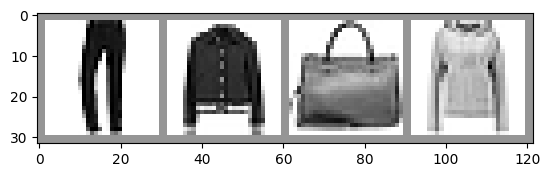

In [4]:
# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# create grid of images
img_grid = torchvision.utils.make_grid(images)

# show images
matplotlib_imshow(img_grid, one_channel=True)

# write to tensorboard
writer.add_image('four_fashion_mnist_images', img_grid)



Depending on how we are using this notebook, we will have different ways to use TensorBoard. One that should work in virtually any environment is to run the following command at the end.

tensorboard --logdir=runs

Another thing we can do with TensorBoard is to visualize the architecture of the model. To do this, we must run the following code


In [5]:
writer.add_graph(net, images)
writer.close()

Another very useful visualization tool is *Projectors*. These generate a low-dimensional representation of high-dimensional data. To do this, we will use the *add_embedding* method. Let's see an example.

In [6]:
# helper function
def select_n_random(data, labels, n=100):
    '''
    Selects n random datapoints and their corresponding labels from a dataset
    '''
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

# select random images and their target indices
images, labels = select_n_random(trainset.data, trainset.targets)

# get the class labels for each image
class_labels = [classes[lab] for lab in labels]

# log embeddings
features = images.view(-1, 28 * 28)
writer.add_embedding(features,
                    metadata=class_labels,
                    label_img=images.unsqueeze(1))
writer.close()

In TensorBoard, we should have one more tab containing the information generated by the Projector.

Next, we will see another example, in this case of how to generate information about the evolution of the loss function (*loss*), as well as a view of the predictions that the *plot_classes_pred* model is generating. To do this, we need to define a couple of functions.


In [7]:
# helper functions

def images_to_probs(net, images):
    '''
    Generates predictions and corresponding probabilities from a trained
    network and a list of images
    '''
    output = net(images)
    # convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = np.squeeze(preds_tensor.numpy())
    return preds, [F.softmax(el, dim=0)[i].item() for i, el in zip(preds, output)]


def plot_classes_preds(net, images, labels):
    '''
    Generates matplotlib Figure using a trained network, along with images
    and labels from a batch, that shows the network's top prediction along
    with its probability, alongside the actual label, coloring this
    information based on whether the prediction was correct or not.
    Uses the "images_to_probs" function.
    '''
    preds, probs = images_to_probs(net, images)
    # plot the images in the batch, along with predicted and true labels
    fig = plt.figure(figsize=(12, 48))
    for idx in np.arange(4):
        ax = fig.add_subplot(1, 4, idx+1, xticks=[], yticks=[])
        matplotlib_imshow(images[idx], one_channel=True)
        ax.set_title("{0}, {1:.1f}%\n(label: {2})".format(
            classes[preds[idx]],
            probs[idx] * 100.0,
            classes[labels[idx]]),
                    color=("green" if preds[idx]==labels[idx].item() else "red"))
    return fig

To make use of the above function, *plot_classes_pred* we have to use it in the context of a training loop. Let's see how it is integrated.

In [8]:
running_loss = 0.0
for epoch in range(1):  # loop over the dataset multiple times

    for i, data in enumerate(trainloader, 0):

        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:    # every 1000 mini-batches...

            # ...log the running loss
            writer.add_scalar('training loss',
                            running_loss / 1000,
                            epoch * len(trainloader) + i)

            # ...log a Matplotlib Figure showing the model's predictions on a
            # random mini-batch
            writer.add_figure('predictions vs. actuals',
                            plot_classes_preds(net, inputs, labels),
                            global_step=epoch * len(trainloader) + i)
            running_loss = 0.0
print('Finished Training')

Finished Training


If we open Tensorboard, and reload, we will see a new *Scalars* tab where we can visualize the evolution of the loss function value over time.

In the *Images* tab, after reloading its content, we will see a version of the image showing random examples from the training set, with the predicted labels, the associated probability, and the expected labels.


One last thing we're going to do is generate *PrecisionRecallCurves* to evaluate the accuracy of our classifier.
This metric shows the balance between two metrics for a classifier:

- *Precision*: Indicates the precision of the model and is calculated as *true positives*/*true positives*+*false positives*
- *Recall*: Indicates the degree of completeness and is calculated as *true positives*/*true positives*+*false negatives*

As always, first, we run the Python code that generates the data. Then, we will go to Tensorboard to see the results in a new tab that will be generated called *PR Curves*.



In [9]:
# 1. gets the probability predictions in a test_size x num_classes Tensor
# 2. gets the preds in a test_size Tensor
# takes ~10 seconds to run
class_probs = []
class_label = []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        output = net(images)
        class_probs_batch = [F.softmax(el, dim=0) for el in output]

        class_probs.append(class_probs_batch)
        class_label.append(labels)

test_probs = torch.cat([torch.stack(batch) for batch in class_probs])
test_label = torch.cat(class_label)

# helper function
def add_pr_curve_tensorboard(class_index, test_probs, test_label, global_step=0):
    '''
    Takes in a "class_index" from 0 to 9 and plots the corresponding
    precision-recall curve
    '''
    tensorboard_truth = test_label == class_index
    tensorboard_probs = test_probs[:, class_index]

    writer.add_pr_curve(classes[class_index],
                        tensorboard_truth,
                        tensorboard_probs,
                        global_step=global_step)
    writer.close()

# plot all the pr curves
for i in range(len(classes)):
    add_pr_curve_tensorboard(i, test_probs, test_label)

# Exercise

Using the code resulting from the exercise at the end of the *optimizers.ipynb* notebook as the basis, make the necessary changes to record the figure of the comparison of the loss_function between the 3 optimizers. Then check that you can visualize it. The solution to this exercise is provided directly for viewing.

In [ ]:
# Import libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchmetrics import HammingDistance, F1Score, MetricCollection

from torch.utils.tensorboard import SummaryWriter
# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/cifar10_experiment_1')

# We initialize the model, the metric and the optimizer
metrics = MetricCollection([HammingDistance(task='multiclass', num_classes=10), F1Score(task='multiclass',num_classes=10, threshold=0.5)])

# Load CIFAR-10 dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

# Define the network architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Define the loss function
loss_func = nn.CrossEntropyLoss()

# Define the training function
def train(net, trainloader, optimizer, num_epochs=2):
    loss_values = []
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()

            # save losses to plot later
            running_loss += loss.item()
            if i % 2000 == 1999:  # print every 2000 mini-batches
                loss_values.append(running_loss / 2000)
                running_loss = 0.0
                metrics(torch.argmax(outputs,dim=1), labels)
                 # ...log the running loss
                writer.add_scalar('training loss',
                            running_loss / 2000,
                            epoch * len(trainloader) + i)
        
print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader)}")
print(f"Epoch {epoch+1}, Metrics: {metrics.compute()}")
        # We reset the metric for the next epoch
        metrics.reset()

    return loss_values

# SGDs
net_SGD = Net()
optimizer_SGD = optim.SGD(net_SGD.parameters(), lr=0.001, momentum=0.9)
loss_SGD = train(net_SGD, trainloader, optimizer_SGD)

Files already downloaded and verified
